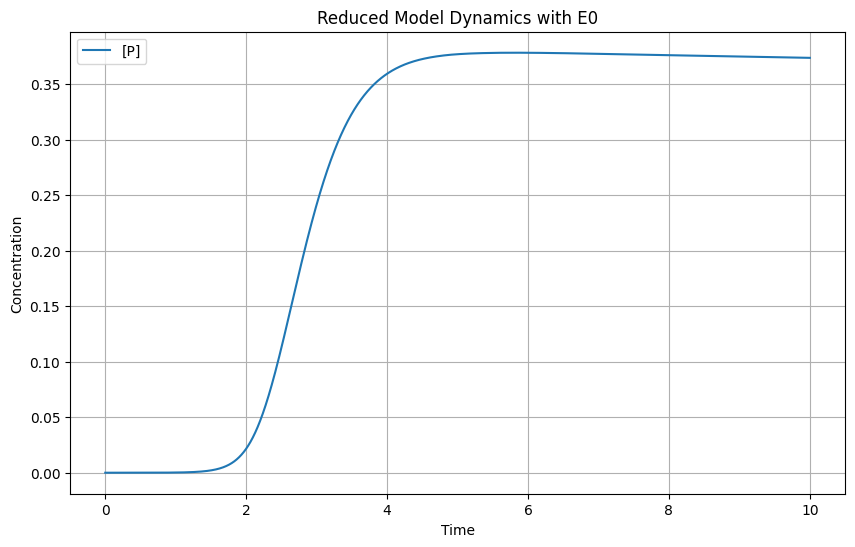

In [ ]:

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

def model(t, y, E0):
    S, P,Q, H2O2, E_O = y

    # Free enzyme concentration [E]
    E = E0 - E_O

    # Reaction rates
    v_cat = k_cat * E_O * S / (K_M_S + S)
    v_auto = k_auto * E * H2O2 * P / ((K_M_H2O2 + H2O2) * (K_M_P + P))
    v_disprop_1 = k_disprop * P**2
    v_disprop_2 = k_disprop * P**2 * H2O2 
    v_side = k_side * S * Q

    # Differential equations
    dS_dt = v_disprop_1 + v_disprop_2 - v_cat - v_side
    dP_dt = v_cat + v_side - 2*(v_disprop_1 + v_disprop_2)
    dH2O2_dt = -(v_auto + v_disprop_2)
    dE_O_dt = v_auto - v_cat
    dQ_dt = v_disprop_2 - v_side


    return [dS_dt, dP_dt, dQ_dt, dH2O2_dt, dE_O_dt]

# Initial conditions
S0 = 10.0
P0 = 1e-6
H2O2_0 = 100.0
E_O0 = 0
y0 = [S0, P0, H2O2_0, E_O0]

# Parameters
k_cat = 10.0      # Catalytic rate constant
k_auto = 5    # Autocatalytic rate constant
k_side = 0.1    # Side reaction rate constant
k_disprop = 1.5  # Disproportionation rate constant
K_M_H2O2 = 1    # Michaelis constant for H2O2
K_M_S = 10       # Michaelis constant for S
K_M_P = 0.1       # Michaelis constant for P
E0 = 0.02

# Time range
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Total enzyme concentration
E0 = 0.2

# Solve the ODEs
solution = solve_ivp(model, t_span, y0, t_eval=t_eval, method='LSODA', args=(E0,))

# Extract results
S, P, H2O2, E_O = solution.y

# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# plt.plot(solution.t, S, label='[S]')
plt.plot(solution.t, P, label='[P]')
# plt.plot(solution.t, H2O2, label='[H2O2]')
# plt.plot(solution.t, E_O, label='[E_O]')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Reduced Model Dynamics with E0')
plt.legend()
plt.grid()
plt.show()


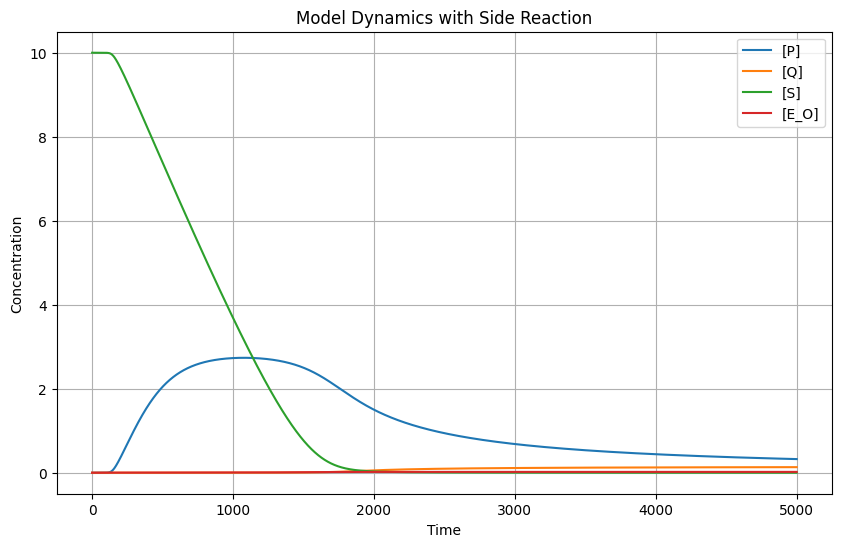

In [ ]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

def model(t, y, E0):
    S, P, Q, H2O2, E_O = y

    # Free enzyme concentration [E]
    E = E0 - E_O

    # Reaction rates
    v_cat = k_cat * E_O * S / (K_M_S + S)
    v_auto = k_auto * E * H2O2 * P / ((K_M_H2O2 + H2O2) * (K_M_P + P))
    v_disprop_1 = k_disprop * P**2
    v_disprop_2 = k_disprop * P**2 * H2O2 
    v_side = k_side * S * Q

    # Differential equations
    dS_dt = v_disprop_1 + v_disprop_2 - v_cat - v_side
    dP_dt = v_cat + v_side - 2*(v_disprop_1 + v_disprop_2)
    dQ_dt = v_disprop_2 - v_side
    dR_dt = v_side + v_disprop_1
    dH2O2_dt = -(v_auto + v_disprop_2)
    dE_O_dt = v_auto - v_cat

    return [dS_dt, dP_dt, dQ_dt, dR_dt, dH2O2_dt, dE_O_dt]

# Initial conditions
S0 = 10.0         # Initial concentration of S
P0 = 1e-7         # Initial concentration of P
Q0 = 0.0          # Initial concentration of Q
H2O2_0 = 100.0    # Initial concentration of H2O2
E_O0 = 0          # Initial concentration of E_O
y0 = [S0, P0, Q0, H2O2_0, E_O0]  # Initial state vector

# Parameters
k_cat = 5      # Catalytic rate constant
k_auto = 0.5        # Autocatalytic rate constant
k_side = 1      # Side reaction rate constant
k_disprop = 0.00001   # Disproportionation rate constant
K_M_H2O2 = 1      # Michaelis constant for H2O2
K_M_S = 10        # Michaelis constant for S
K_M_P = 0.1       # Michaelis constant for P
E0 = 0.02          # Total enzyme concentration

# Time range
t_span = (0, 5000)  # Time interval for integration
t_eval = np.linspace(t_span[0], t_span[1], 5000)  # Time points for evaluation

# Solve the ODEs
solution = solve_ivp(model, t_span, y0, t_eval=t_eval, method='LSODA', args=(E0,), rtol=1e-8, atol=1e-8)

# Extract results
S, P, Q, H2O2, E_O = solution.y

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(solution.t, P, label='[P]')
plt.plot(solution.t, Q, label='[Q]')
plt.plot(solution.t, S, label='[S]')
# plt.plot(solution.t, H2O2, label='[H2O2]')
plt.plot(solution.t, E_O, label='[E_O]')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Model Dynamics with Side Reaction')
plt.legend()
plt.grid()
plt.show()

